# Met Office PyEarthTools Machine Learning Demo Project

This project will demonstrate how to develop a model that can predict meteorological variables in the future using Met Office UKV data, PyEartTools and PyTorch. <br>
* We will create PyEarthTools pipelines that can package data (T+0 and T+x) and will use T+0 as our input data and T+x as our target data.
* We will use 6 input variables (inlcuding 1 constant) from the UKV dataset to predict 5 output variables.

This project will demonstrate how to: 
* Access Met Office Site Archive data (UKV) using the PyEarthTools archive system.
* Create PyEarthTools data pipelines to process the data into train, validate and test pipelines with iterators.
* Develop a PyTorch ML project which will use a PyEarthTools data pipeline for input ML data.

**Notes:**
* To substantially reduce training time on internal CPU compute architecture we have done the following to this project:
    * Reduced the training data timeseries to just a few months,
    * Reduced the variables to 6
    * Downsampled the data by a factor of 4 when training.
* This will also effect model training performance, feel free to expand if you have the computational resources to develop a more accurate model.
* This project was run on Jupyter Hub Azure with 42 threads and 32GB RAM.

## Setup

Import PyEarthTools modules and the met office site archive to connect to data stored on disk. 

In [1]:
import pyearthtools
from pyearthtools import data, pipeline

import site_archive_met_office

ROOT_DIRECTORIES: {'ERA5lowres': '/data/users/dscop/weatherbench/5.625deg/', 'MOGLOBAL': '/data/users/dscop/pyearthtools_data/mo_global/', 'MOUKV': '/data/users/dscop/pyearthtools_data/mo_ukv/'}


## Create UKV PyEarthTools Data Accessor

We have created a demo UKV dataset on disk with a few variables to play with from the year 2018. Therefore our project will need to only use data for this period. <br> 
However, it is possible to add more data to the data to the dscop datadir, or point the PyEarthTools data accessor to your own version of the dataset using the `.set_root_directory('/your/data/location')` method. 


In [2]:
variables = [
    "air_temperature",
    "air_pressure_at_sea_level",
    "x_wind",
    "y_wind",
    "specific_humidity",
    "surface_altitude",
]
# variables = ['air_temperature', 'air_pressure_at_sea_level']

ukv_accessor = pyearthtools.data.archive.MOUKV(variables)
ukv_accessor

MOUKV
	Description                    Met Office UKV (subset)
		 range                          '2018'
		 Documentation                  'https://www.metoffice.gov.uk/binaries/content/assets/metofficegovuk/pdf/data/ukv_model_data_sheet_2019.pdf'


	Initialisation                 
		 level_value                    None
		 variables                      ['air_temperature', 'air_pressure_at_sea_level', 'x_wind', 'y_wind', 'specific_humidity', 'surface_altitude']
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}
		 Trim                           {'__args': '()', 'variables': "['air_temperature', 'air_pressure_at_sea_level', 'x_wind', 'y_wind', 'specific_humidity', 'surface_altitude']"}
		 Rename                         {'names': {'grid_latitude': "'latitude'", 'grid_longitude': "'longitude'"}}

Lets index into our UKV data accessor with a sample date and review the result to check that our dataset has loaded correctly. 

In [3]:
sample_date = "2018-01-01T03"
ukv_sample_date = ukv_accessor[sample_date]
ukv_sample_date

<xarray.Dataset> Size: 12MB
Dimensions:                    (time: 1, latitude: 810, longitude: 621)
Coordinates:
  * latitude                   (latitude) float32 3kB -3.771 -3.757 ... 7.151
  * longitude                  (longitude) float64 5kB 354.9 354.9 ... 363.3
  * time                       (time) datetime64[ns] 8B 2018-01-01T03:00:00
Data variables:
    x_wind                     (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    air_pressure_at_sea_level  (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    surface_altitude           (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    air_temperature            (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    y_wind                     (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    specific_humidity          (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
Attributes:
    source:       Data from Met Office Unified Model
    um_version:   10.6
    Conventions:  CF-1.7

## Visualise the data

It is useful to visualise our input data to check it has loaded correctly. We will also use this technique later to quickly compare our ML model results.

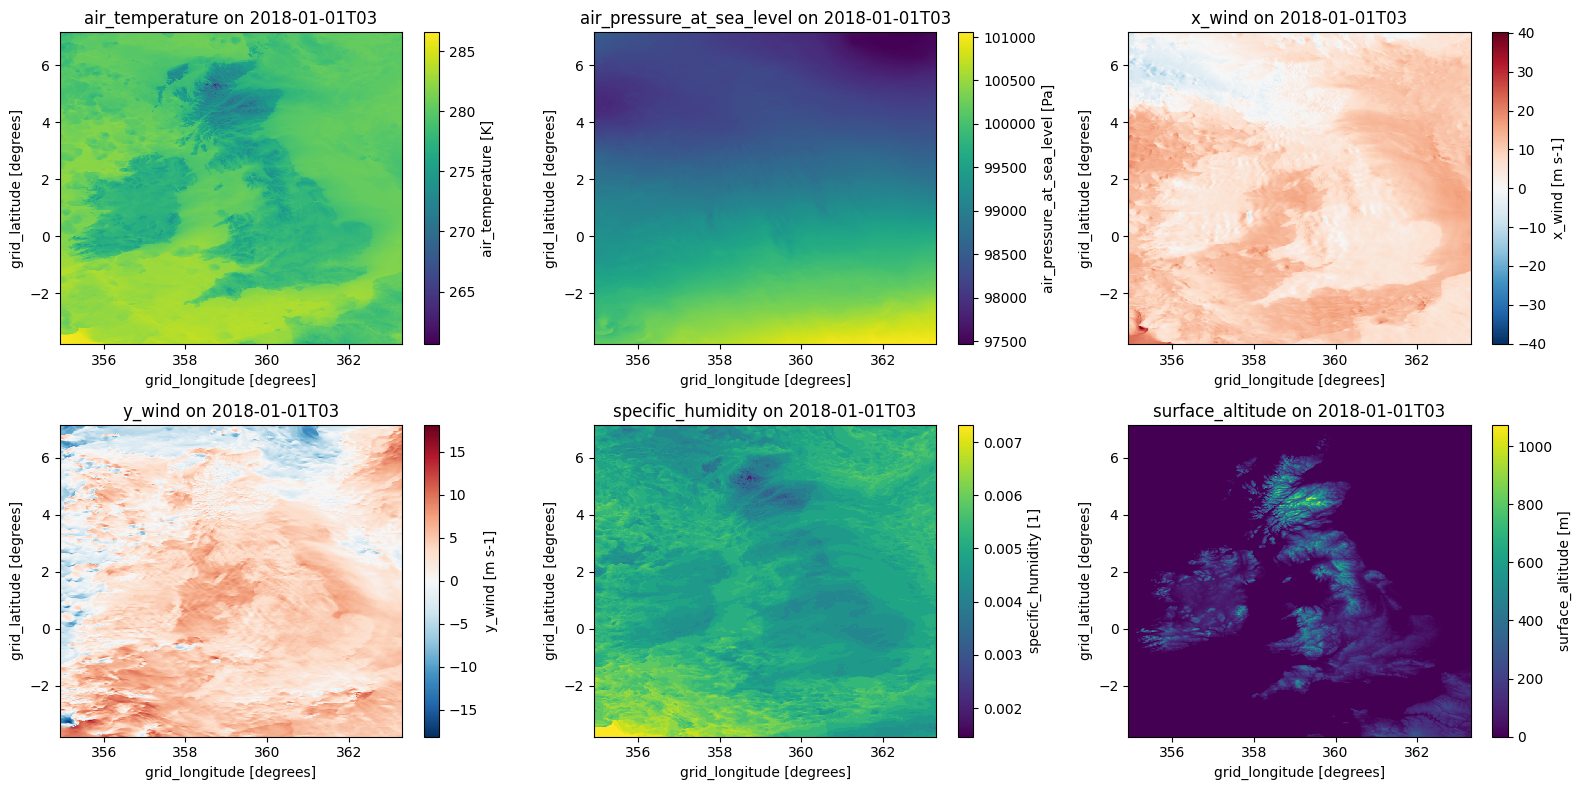

In [4]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 3, figsize=(16, 8))

for ax, var in zip(axs.flat, variables):
    ukv_sample_date[var].plot(ax=ax)
    ax.set_title(f"{var} on {sample_date}")

plt.tight_layout()
plt.show()

## Data Processing Pipelines

Now we have loaded the raw data we need to process it to work with ML libraries.

In [5]:
# Used to store the MagicNorm normalisation files
import os

workdir = os.getcwd()
norm_cache_dir = os.path.join(workdir, "norm_cache_dir")
os.makedirs(norm_cache_dir, exist_ok=True)

We will split our data into 3 groups with start and end dates that should not overlap to prevent data leakage:
* `Train` - this is the data our model will learn from.
* `Validate` - used during training to evaluate model training.
* `Test` - data is held back to test with after the model is trained. 

In [6]:
train_start_date = "2018-01-01T03"
train_end_date = "2018-09-30T03"

validate_start_date = "2018-10-01T03"
validate_end_date = "2018-10-14T03"

test_start_date = "2018-10-15T03"
test_end_date = "2018-10-28T03"

interval = "6 hours"

We will create a data pipeline for each of our data sources (train, validate and test). <br>
Our data processing pipelines need to do the following:
* Use the `ukv_accessor` to access the data. 
* Ensure our data is on a `standard longitudinal grid`. 
* `Flatten` the data if it is on pressure levels. 
* Split the data using `TemporalRetrieval` into input (T+0) and target (T+6) data.
* `Normalise` the data with the PyEarthTools MagicNorm functionality. 
* Convert the data to `numpy` to work with ML libraries. 
* `Squeeze` the data to remove unneeded dimensions. 
* Create a `sampler` and `iterator` to create an iterable which will be used to generate samples for ML training



In [7]:
# TRAINING PIPELINE

data_pipeline = pyearthtools.pipeline.Pipeline(
    ukv_accessor,
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="-180-180"),
    # Uncomment the line below if working with multi-level data
    # pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten("level"),
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True, samples=((0, 1), (6, 1))  # Input = 1 sample T=0 hours. Target = T+6
    ),
    pyearthtools.pipeline.operations.xarray.normalisation.MagicNorm(
        cache_dir=norm_cache_dir
    ),  # Incremental normalisation calculator
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Rearrange(
        "c t h w -> t c h w"
    ),  # channel time height width -> time channel height width
    pyearthtools.pipeline.operations.numpy.reshape.Squeeze(axis=0),
    sampler=pyearthtools.pipeline.samplers.Default(),
    iterator=pyearthtools.pipeline.iterators.DateRange(train_start_date, train_end_date, interval=interval),
)

# data_pipeline

In [8]:
# VALIDATION PIPELINE

validate_pipeline = pyearthtools.pipeline.Pipeline(
    ukv_accessor,
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="-180-180"),
    # Uncomment the line below if working with multi-level data
    # pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten("level"),
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True, samples=((0, 1), (6, 1))  # Input = 1 sample T=0 hours. Target = T+6
    ),
    pyearthtools.pipeline.operations.xarray.normalisation.MagicNorm(
        cache_dir=norm_cache_dir
    ),  # Incremental normalisation calculator
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Rearrange(
        "c t h w -> t c h w"
    ),  # channel time height width -> time channel height width
    pyearthtools.pipeline.operations.numpy.reshape.Squeeze(axis=0),
    sampler=pyearthtools.pipeline.samplers.Default(),
    iterator=pyearthtools.pipeline.iterators.DateRange(validate_start_date, validate_end_date, interval=interval),
)

# validate_pipeline

In [9]:
# TEST PIPELINE

test_pipeline = pyearthtools.pipeline.Pipeline(
    ukv_accessor,
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="-180-180"),
    # Uncomment the line below if working with multi-level data
    # pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten("level"),
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True, samples=((0, 1), (6, 1))  # Input = 1 sample T=0 hours. Target = T+6
    ),
    pyearthtools.pipeline.operations.xarray.normalisation.MagicNorm(
        cache_dir=norm_cache_dir
    ),  # Incremental normalisation calculator
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Rearrange(
        "c t h w -> t c h w"
    ),  # channel time height width -> time channel height width
    pyearthtools.pipeline.operations.numpy.reshape.Squeeze(axis=0),
    sampler=pyearthtools.pipeline.samplers.Default(),
    iterator=pyearthtools.pipeline.iterators.DateRange(test_start_date, test_end_date, interval=interval),
)

# test_pipeline

It is useful to review some basic statistics of our data to understand and check:
* `Shape` (num of variables, width, height) and that the input and target shapes match. 
* `Values` - check that values have been normalised / scaled. 
* Check for `NaN` values.

In [10]:
import numpy as np

# Review some data information (note the shape - this will be useful)
for inp, tgt in data_pipeline:
    print("Input Type:", type(inp), "Target Type", type(tgt))
    print("Input Shape:", inp.shape, "Target Shape:", tgt.shape)
    print("Input Dtype:", inp.dtype)
    print("First few Input values:", inp.ravel()[:10])
    print("First few Target values:", tgt.ravel()[:10])
    print("inp NaN count:", np.isnan(inp).sum())
    print("tgt NaN count:", np.isnan(tgt).sum())
    break  # Just to check the first batch

Input Type: <class 'numpy.ndarray'> Target Type <class 'numpy.ndarray'>
Input Shape: (6, 810, 621) Target Shape: (6, 810, 621)
Input Dtype: float32
First few Input values: [2.5236518 2.5037796 2.4839075 2.4640353 2.444163  2.4044187 2.3845468
 2.3845468 2.3845468 2.3845468]
First few Target values: [0.8543907  0.8543907  0.8543907  0.8543907  0.8742628  0.8742628
 0.89413494 0.89413494 0.9140071  0.93387926]
inp NaN count: 0
tgt NaN count: 0


## Machine Learning Code

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import time

#### U-Net Style Model Architecture 
Below we will create a simplified U-net like Convolutional Neural Network (CNN) Model Class for demonstration purposes. <br>
This approach has proven effective for image-based problems and is applicable to wider problem types. <br>
You might want to experiment with making adding more layers, and also wider with larger values, however this will probably increase training time.  

In [12]:
class CNN_Model(nn.Module):
    """
    A convolutional neural network based on the U-net architecture.
    """

    def __init__(self, in_channels, out_channels, dropout):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool2d(2),
        )

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv2d(512, 256, 3, padding=1),
            nn.ReLU(),
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),  # 100x76 → 200x152
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),  # 200x152 → 400x304
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # 400x304 → 800x608
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv2d(32, out_channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x)
        return x

#### Training Parameters.<br> 
* If you have access to a `GPU` you might want to use device agnostic code to attempt to train on a GPU for substancially increased training times. 

* You might notice our `width` and `height` values are different. This is because our model above uses `MaxPooling` where the image dimensionality is reduced by a factor of 2 (or more potentially). However the original dimensions of the dataset are 810 * 621. If we try and half 621 and result in an integer value we will have issues. Whilst we can half 810 to 405, if we were to max pool again we would again face the same issue. To handle this we could pad the image with zero values, but in this case we will reduce the dimensionality of the image to a number that can be divided by 16 (800 by 608).

You may want to experiment with:
* `epoches` which define the number of times our training loop iterates over the training data.
* `batch_size` which controls how many samples are processed together before updating model weights. The higher the number, the more memory you will need for training.  
* `optimizers` and optimizer `learning_rate`.
* `dropout` which randomly sets a fraction of the neuron outputs to 0 - helps with overfitting. 

In [13]:
# Training Parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

in_channels = len(variables)
out_channels = len(variables) - 1  # -1 to remove the surface_altitude constant.
width = 800
height = 608

epochs = 16
batch_size = 1
dropout = 0.2

model = CNN_Model(in_channels=in_channels, out_channels=out_channels, dropout=dropout)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.L1Loss()

#### Training Loop
Here we iterate through the PyEarthTools data pipeline to produce input and target samples: `for inp, tgt in tqdm(data_pipeline):` 

In [14]:
# Define the training loop code
from scipy.ndimage import zoom
from tqdm import tqdm

# Downsample factor for training to reduce memory usage and speed up training
downsample_factor = 0.25


def downsample(x, factor):
    zoomed = zoom(x, (1, factor, factor), order=1)
    return zoomed


# Loss function
def calculate_loss(model, x, y):
    y_preds = model(x)  # (B, C, H, W)

    # Compute per-channel MSE
    # mean over batch + spatial dims, keep channels separate
    per_channel_loss = ((y_preds - y) ** 2).mean(dim=[0, 2, 3])

    # Average across channels → scalar loss
    loss = per_channel_loss.mean()
    return loss


def train_epoch(batch_size):
    inp_batch = []
    tgt_batch = []
    i = 0
    lossper = 0
    tic = time.perf_counter()

    for inp, tgt in tqdm(data_pipeline):

        # Remove the altitude constant from the target
        tgt = tgt[:-1, :, :]

        # Crop the dimensions so they are divisible by 16 for maxpool layers
        inp_cropped = inp[..., :width, :height]
        tgt_cropped = tgt[..., :width, :height]

        # Downsample the data to reduce memory usage and speed up training
        inp_cropped = downsample(inp_cropped, downsample_factor)
        tgt_cropped = downsample(tgt_cropped, downsample_factor)

        inp_batch.append(inp_cropped)
        tgt_batch.append(tgt_cropped)

        if len(inp_batch) == batch_size:
            inp_tensor = torch.tensor(np.array(inp_batch), dtype=torch.float32, device=device)
            # Remove the last channel from the target batch (axis=1)
            tgt_np = np.array(tgt_batch)

            # Only slice if tgt_np.shape[1] == 6
            if tgt_np.shape[1] == 6:
                tgt_np = tgt_np[:, :-1, :, :]  # Remove last channel

            tgt_tensor = torch.tensor(tgt_np, dtype=torch.float32, device=device)

            optimizer.zero_grad()
            loss = calculate_loss(model, inp_tensor, tgt_tensor)
            loss.backward()
            optimizer.step()
            lossper += loss.item()
            i += 1

            inp_batch = []
            tgt_batch = []

    toc = time.perf_counter()
    if i > 0:
        average_loss = lossper / i
        duration = toc - tic
        print(f"Epoch finished: {i} batches")
        print(f"Average loss over epoch: {average_loss}")
        print(f"Duration for epoch: {duration}")
        return average_loss
    else:
        print("No batches processed this epoch.")


def validate_epoch():
    model.eval()
    val_loss = 0
    count = 0
    with torch.no_grad():
        for inp, tgt in validate_pipeline:
            inp_cropped = inp[..., :width, :height]
            tgt_cropped = tgt[..., :width, :height]

            # Remove the constant variable (e.g., last channel) from the target
            if tgt_cropped.shape[0] == 6:
                tgt_cropped = tgt_cropped[:-1, :, :]  # Remove last channel

            # Downsample the data to reduce memory usage and speed up training
            inp_cropped = downsample(inp_cropped, downsample_factor)
            tgt_cropped = downsample(tgt_cropped, downsample_factor)

            inp_tensor = torch.tensor(inp_cropped, dtype=torch.float32, device=device).unsqueeze(0)
            tgt_tensor = torch.tensor(tgt_cropped, dtype=torch.float32, device=device).unsqueeze(0)

            output = model(inp_tensor)

            loss = loss_fn(output, tgt_tensor)
            val_loss += loss.item()
            count += 1
    avg_val_loss = val_loss / count if count > 0 else float("nan")
    print(f"Validation loss: {avg_val_loss}")
    model.train()
    return avg_val_loss

In [15]:
train_losses = []
val_losses = []


def do_train(epochs):
    for i in range(epochs):
        print(f"Commencing epoch {i}")

        # Training
        avg_train_loss = train_epoch(batch_size=batch_size)
        train_losses.append(avg_train_loss)

        # Validation
        avg_val_loss = validate_epoch()
        val_losses.append(avg_val_loss)

#### Commence Training...
The cell below will start the training process. <br>
You can train the model yourself, however if you lack the time/compute to do so you can download the weights from this notebook here: https://github.com/JMP-MO/ML_weights/raw/refs/heads/main/moukv_model_weights.pth <br>
Add the weights file to the same directory as this notebook and change `enable_training` to False to load the weights file instead. <br>
⚠️ Training might take some time and also use a significant amount of memory.

In [16]:
%%time

from pathlib import Path

enable_training = True

weights_file = os.path.join(workdir, "moukv_model_weights.pth")

if enable_training:
    print("Training commencing...")
    do_train(epochs=epochs)
    torch.save(model.state_dict(), weights_file)
else:
    if os.path.exists(weights_file):
        print("Loading saved model weights")
        model.load_state_dict(torch.load(weights_file))

Training commencing...
Commencing epoch 0


100%|██████████| 1088/1088 [05:15<00:00,  3.45it/s]


Epoch finished: 1088 batches
Average loss over epoch: 0.8782546220292502
Duration for epoch: 315.6780334759969
Validation loss: 0.7530969593387383
Commencing epoch 1


100%|██████████| 1088/1088 [03:27<00:00,  5.25it/s]


Epoch finished: 1088 batches
Average loss over epoch: 0.8237370152902954
Duration for epoch: 207.3546912749298
Validation loss: 0.7675973881895726
Commencing epoch 2


...

Epoch finished: 1088 batches
Average loss over epoch: 0.5558846579070258
Duration for epoch: 217.26253134501167
Validation loss: 0.6113053692074922
Commencing epoch 14


100%|██████████| 1088/1088 [03:51<00:00,  4.70it/s]


Epoch finished: 1088 batches
Average loss over epoch: 0.5509869583663257
Duration for epoch: 231.36367346695624
Validation loss: 0.60921305589951
Commencing epoch 15


100%|██████████| 1088/1088 [04:02<00:00,  4.49it/s]


Epoch finished: 1088 batches
Average loss over epoch: 0.5488195386441315
Duration for epoch: 242.20694058109075
Validation loss: 0.6109006788868171
CPU times: user 10h 22min 49s, sys: 5min 22s, total: 10h 28min 11s
Wall time: 1h 5min 5s


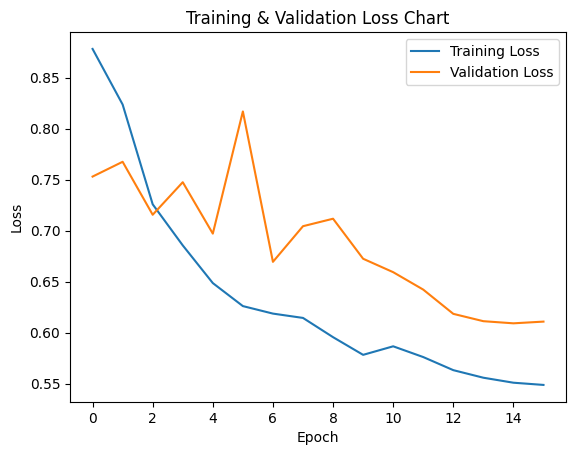

In [17]:
# Train and Validation Loss Chart
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training & Validation Loss Chart")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [18]:
# Load the model we saved earlier!
model = CNN_Model(in_channels=in_channels, out_channels=out_channels, dropout=dropout)
model.load_state_dict(torch.load(weights_file, map_location=device))
model.to(device)
model.eval()

CNN_Model(
  (encoder): Sequential(
    (0): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): Dropout(p=0.2, inplace=False)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU()
    (13): Dropout(p=0.2, inplace=False)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bottleneck): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Conv2d(512, 

In [19]:
# Perform inference on the test dataset

from tqdm import tqdm

for inp, tgt in tqdm(test_pipeline):

    # Crop the dimensions so they are divisible by 16 for maxpool layers
    inp_cropped = inp[..., :width, :height]
    tgt_cropped = tgt[..., :width, :height]

    # # Some data in the pipeline has mismatching shapes, for now we will skip these.
    # expected_shape = (channels, width, height)
    # if inp_cropped.shape != expected_shape or tgt_cropped.shape != expected_shape:
    #     print(f"Skipping batch: input shape {inp_cropped.shape}, target shape {tgt_cropped.shape}, expected {expected_shape}")
    #     continue

    # Downsample the data to reduce memory usage and speed up training
    inp_cropped = downsample(inp_cropped, downsample_factor)
    tgt_cropped = downsample(tgt_cropped, downsample_factor)

    inp_tensor = torch.tensor(inp_cropped, dtype=torch.float32, device=device).unsqueeze(0)  # Add batch dimension
    tgt_tensor = torch.tensor(tgt_cropped, dtype=torch.float32, device=device).unsqueeze(0)  # Add batch dimension

    with torch.no_grad():
        output = model(inp_tensor)

    # Move tensors to CPU and convert to numpy arrays
    inp_np = inp_tensor.squeeze(0).cpu().numpy()  # Remove batch dimension
    tgt_np = tgt_tensor.squeeze(0).cpu().numpy()  # Remove batch dimension
    pred_np = output.squeeze(0).cpu().numpy()  # Remove batch dimension

    # Now inp_np, tgt_np, and pred_np can be used for further analysis or visualization
    print("Input shape:", inp_np.shape)
    print("Target shape:", tgt_np.shape)
    print("Prediction shape:", pred_np.shape)

    break  # Just process one batch for demonstration

  0%|          | 0/52 [00:00<?, ?it/s]

Input shape: (6, 200, 152)
Target shape: (6, 200, 152)
Prediction shape: (5, 200, 152)


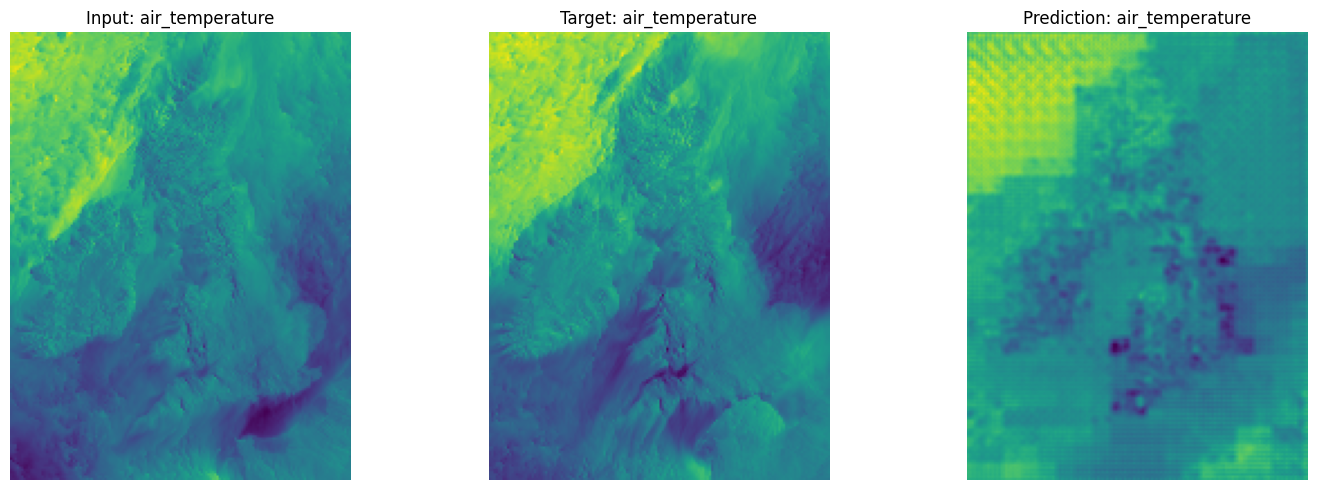

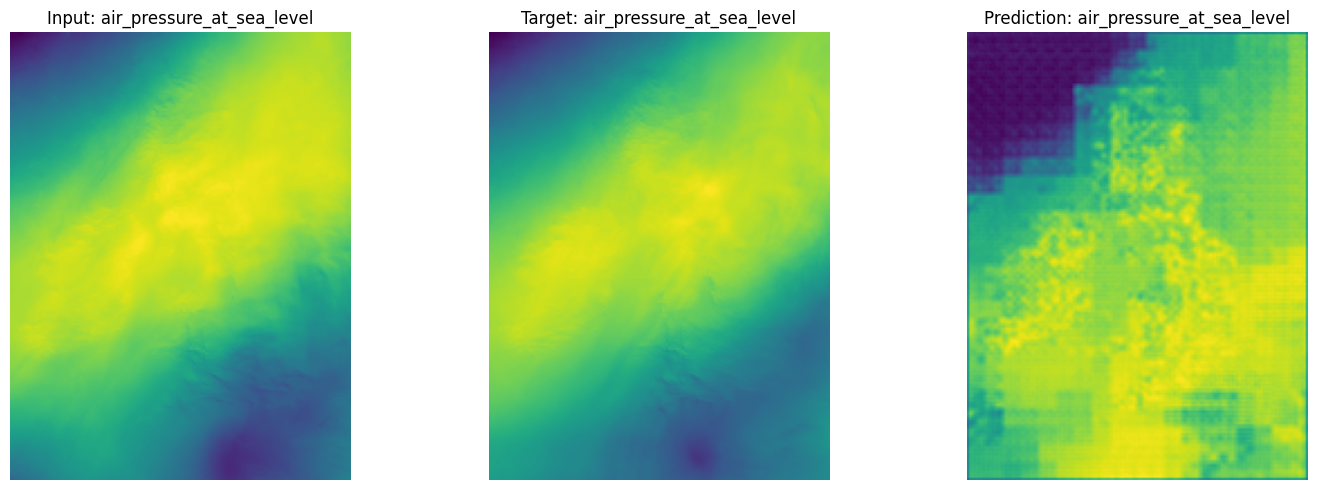

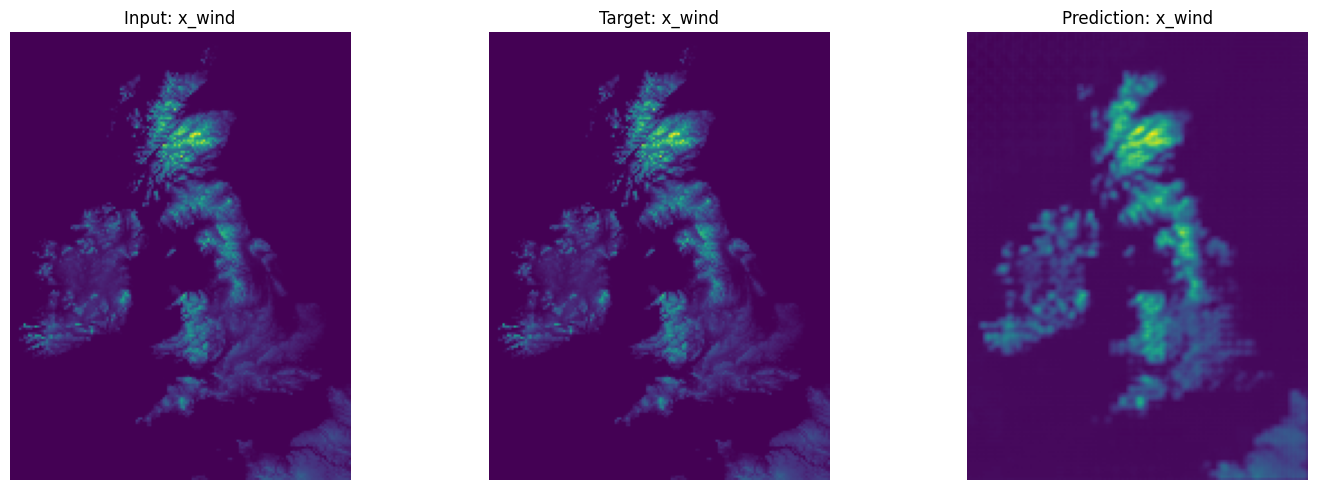

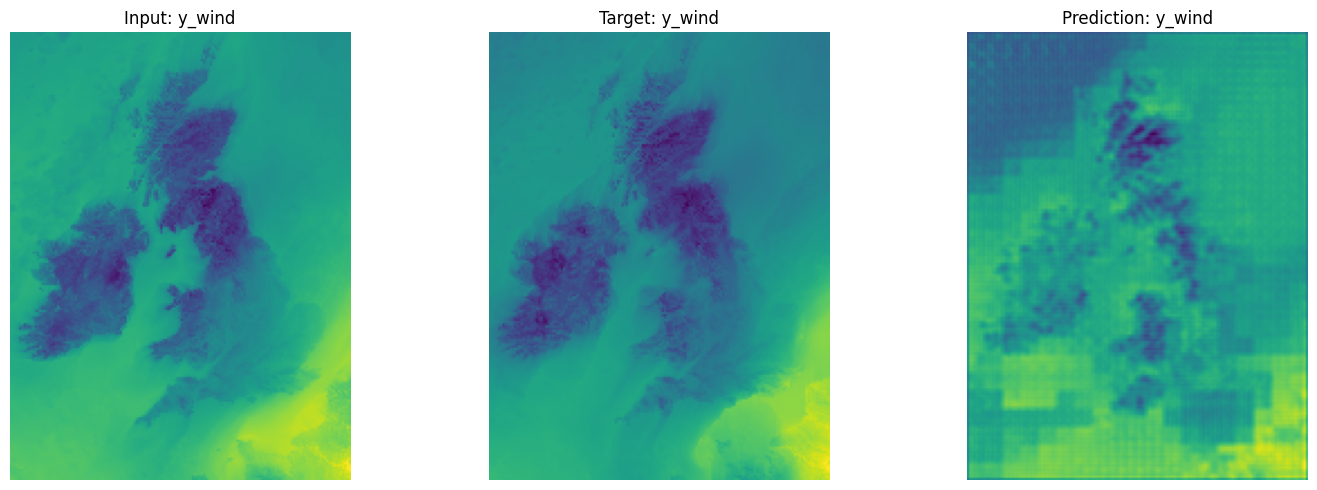

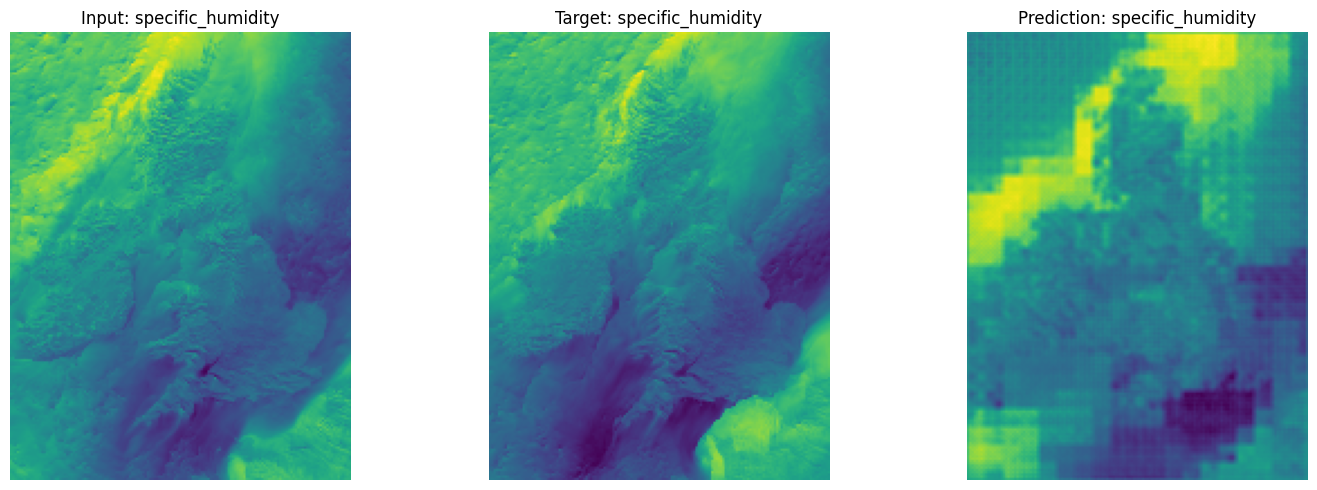

In [20]:
# Visualise for each variable/channel (except surface_altitude constant)
# Remember we reduced the resolution hense the 'blocky' prediction output.
for i, var in enumerate(variables[:-1]):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(inp_np[i], cmap="viridis", origin="lower")
    axs[0].set_title(f"Input: {var}")
    axs[1].imshow(tgt_np[i], cmap="viridis", origin="lower")
    axs[1].set_title(f"Target: {var}")
    axs[2].imshow(pred_np[i], cmap="viridis", origin="lower")
    axs[2].set_title(f"Prediction: {var}")
    for ax in axs:
        ax.axis("off")
    plt.tight_layout()
    plt.show()